Load Libraries

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import joblib
import os
import shap
import warnings
warnings.filterwarnings('ignore')

Load Datasets

In [118]:
train_df = pd.read_csv('data/churn_train.csv')
test_df = pd.read_csv('data/churn_test.csv')

Inspect Datasets

In [119]:
print('The Train dataset has {} columns and {} rows'.format(train_df.shape[1], train_df.shape[0]))
print('The Test dataset has {} columns and {} rows'.format(test_df.shape[1], test_df.shape[0]))

The Train dataset has 20 columns and 2666 rows
The Test dataset has 20 columns and 667 rows


In [120]:
train_df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [121]:
test_df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0


Data Cleaning Function

In [122]:
def clean_data(df):
    df = df.copy()
    df['International plan'] = df['International plan'].map({'Yes':1,'No':0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes':1,'No':0})
    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

Feature Engineering Function

In [123]:
def engineer_features(df):
    df = df.copy()
    df['total_minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
    df['total_calls'] = df['Total day calls'] + df['Total eve calls'] + df['Total night calls'] + df['Total intl calls']
    df['cost_per_minute'] = (df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']) / df['total_minutes']
    df['day_night_ratio'] = df['Total day minutes'] / (df['Total night minutes'] + 1)
    df['intl_ratio'] = df['Total intl minutes'] / (df['total_minutes'] + 1)
    df['high_service_calls'] = (df['Customer service calls'] > 3).astype(int)
    return df

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

Exploratory Data Analysis (Train Data)

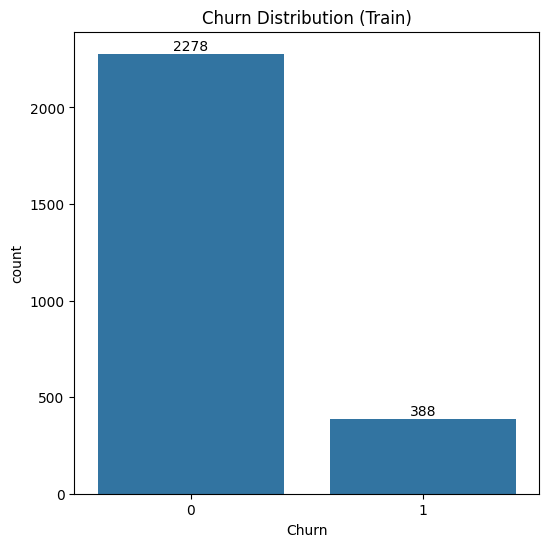

In [124]:
plt.figure(figsize=(6,6))
sns.countplot(x='Churn', data=train_df)
plt.title('Churn Distribution (Train)')

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width()/2., height),
                       ha='center', va='bottom', fontsize=10)
                       
plt.show()

Prepare Datasets

In [125]:
X_train = train_df.drop(columns=['Churn','State','Area code'])
feature_names = X_train.columns 

y_train = train_df['Churn']

X_test = test_df.drop(columns=['Churn','State','Area code'])
y_test = test_df['Churn']

In [126]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

Train Logistic Regression (Baseline Model)

In [127]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])

Logistic Regression Results

In [128]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       572
           1       0.53      0.29      0.38        95

    accuracy                           0.86       667
   macro avg       0.71      0.63      0.65       667
weighted avg       0.84      0.86      0.84       667



In [129]:
print("Logistic ROC-AUC:", log_auc)

Logistic ROC-AUC: 0.870610967979389


Train XGBoost (Advanced Model)

In [130]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

XGBoost Results

In [131]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       572
           1       0.94      0.81      0.87        95

    accuracy                           0.97       667
   macro avg       0.95      0.90      0.93       667
weighted avg       0.96      0.97      0.96       667



In [132]:
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9192307692307691


Compare & Select Best Model

In [133]:
if xgb_auc > log_auc:
    best_model = xgb
    best_model_name = 'xgb'
else:
    best_model = log_model
    best_model_name = 'logistic_regression'

print(f"Best model selected: {best_model_name}")

Best model selected: xgb


Feature Importance

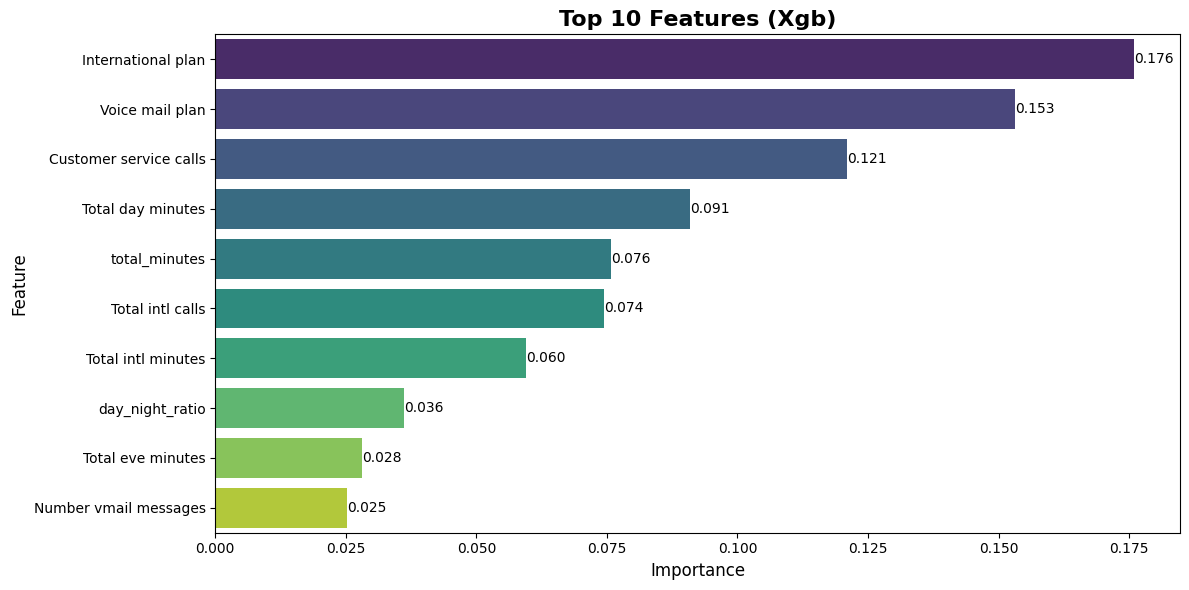

In [134]:
if best_model_name == 'xgb':
    importances = best_model.feature_importances_
elif best_model_name == 'logistic_regression':
    importances = abs(best_model.coef_[0])

feat_df = pd.DataFrame({'Feature': feature_names,'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10), palette='viridis')
plt.title(f'Top 10 Features ({best_model_name.title()})', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)

for p in plt.gca().patches:
    width = p.get_width()
    plt.gca().annotate(f'{width:.3f}', (width, p.get_y() + p.get_height()/2),
                       ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Confusion Matrix

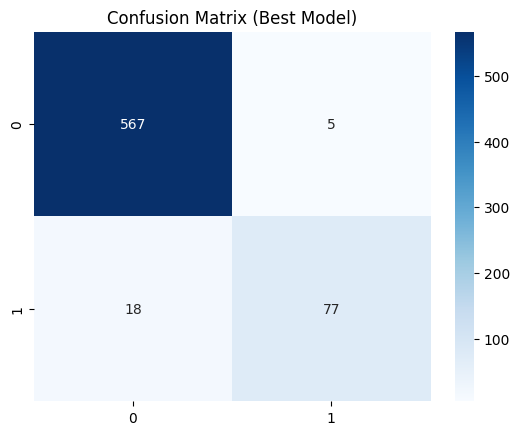

In [135]:
cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Best Model)')
plt.show()

SHAP Explainability (XGBoost Only)

In [136]:
if best_model_name == 'xgb':
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)

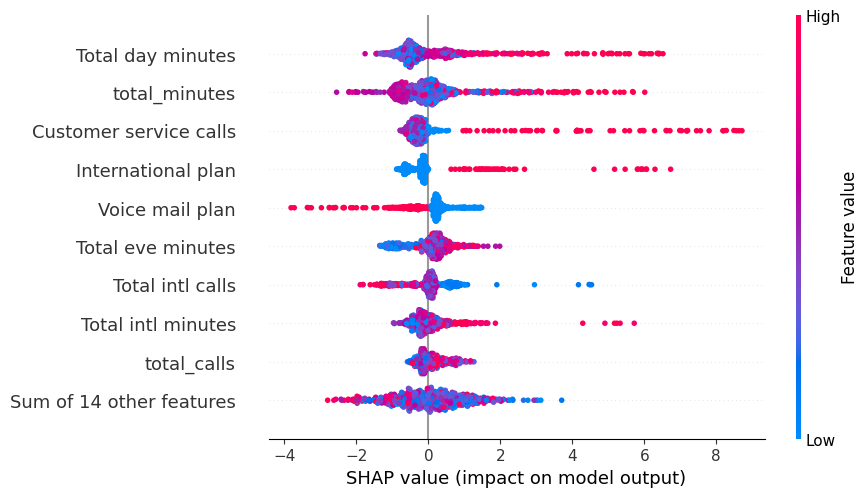

In [137]:
shap.plots.beeswarm(shap_values)

Save Models & Metrics

In [138]:
os.makedirs('models', exist_ok=True)

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(log_model, 'models/log_model.pkl')
best_model.get_booster().save_model("models/best_model.json")

best_model.feature_names = feature_names
joblib.dump(best_model, "best_model.pkl")

metrics = {'logistic_auc': log_auc,'xgb_auc': xgb_auc,'best_model': best_model_name}
joblib.dump(metrics, 'models/metrics.pkl')
print("Models and metrics saved successfully")

Models and metrics saved successfully
